# Práctica: Regresión Lineal para la Detección de Plagas en la Caña de Azúcar

**Objetivo**

El objetivo de esta práctica es aplicar el algoritmo de **Regresión Lineal** para predecir la **pérdida de producción (%)** en un cultivo de caña de azúcar, utilizando variables relacionadas con las condiciones ambientales y el nivel de infestación de plagas.

Equipo 19
Eduardo Murillo Lopez,
Luis Alberto Garcia Lezama,
Eduardo Adan Vichique Hernandez,
Jose Valentin Contreras Gomez

## Creación del dataset

### Cargar las librerías

Se importan las librerías necesarias para el desarrollo de la práctica.

- **Pandas (pd)**: Permite crear y manipular tablas de datos llamadas DataFrames.
- **NumPy (np)**: Se utiliza para generar datos aleatorios y realizar operaciones matemáticas.
- **Matplotlib (plt)**: Permite crear gráficas para visualizar los resultados.
- **Seaborn (sns)**: Complementa a Matplotlib generando gráficas con una mejor presentación.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Crear un dataset ficticio

En este apartado se crea un **dataset ficticio** que simula información obtenida de diferentes parcelas de caña de azúcar.

- `np.random.seed(42)` fija una semilla para que los datos generados sean siempre los mismos al ejecutar el código.
- `n = 300` indica que se crearán **300 registros**.
- `np.random.randint()` genera valores enteros aleatorios dentro de un rango específico para cada variable.
- La variable **Perdida_Produccion** se calcula utilizando una combinación de las demás variables y un pequeño error aleatorio para simular datos más realistas.
- Finalmente, `pd.DataFrame()` organiza toda la información en una tabla llamada `df`.

In [29]:
# Hace que los datos aleatorios sean siempre los mismos
np.random.seed(42)

# Número de registros
n = 300

# Variables independientes
temperatura = np.random.randint(20, 38, n)
humedad = np.random.randint(40, 100, n)
lluvia = np.random.randint(0, 300, n)
edad = np.random.randint(3, 18, n)
plagas = np.random.randint(0, 25, n)
area = np.random.randint(0, 100, n)

# Variable objetivo
perdida = (
    0.8 * plagas +
    0.5 * area +
    0.2 * temperatura +
    0.1 * humedad -
    0.03 * lluvia +
    np.random.normal(0, 5, n)
)

# Crear el DataFrame
df = pd.DataFrame({
    "Temperatura": temperatura,
    "Humedad": humedad,
    "Lluvia": lluvia,
    "Edad_Cultivo": edad,
    "Plagas_Observadas": plagas,
    "Area_Afectada": area,
    "Perdida_Produccion": perdida
})

### Visualizar el dataset

El método `head()` muestra las primeras cinco filas del DataFrame. Esto permite comprobar que los datos se generaron correctamente y verificar la estructura de la tabla.



In [30]:
df.head()

,Temperatura,Humedad,Lluvia,Edad_Cultivo,Plagas_Observadas,Area_Afectada,Perdida_Produccion
0,26,71,216,3,7,89,58.074201
1,34,62,131,14,16,54,50.086538
2,30,61,291,17,6,86,49.451558
3,27,90,69,3,0,38,39.076047
4,26,64,251,12,12,14,15.087071


## Exploración de los datos y Preprocesamiento



### Mostrar información general del dataset

El método `info()` muestra información general del DataFrame: número total de registros, número de columnas, nombre de cada variable, tipo de dato de cada columna y si existen valores nulos.

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Temperatura         300 non-null    int32  
 1   Humedad             300 non-null    int32  
 2   Lluvia              300 non-null    int32  
 3   Edad_Cultivo        300 non-null    int32  
 4   Plagas_Observadas   300 non-null    int32  
 5   Area_Afectada       300 non-null    int32  
 6   Perdida_Produccion  300 non-null    float64
dtypes: float64(1), int32(6)
memory usage: 9.5 KB


### Mostrar estadísticas descriptivas

El método `describe()` calcula estadísticas básicas del conjunto de datos: promedio (mean), desviación estándar (std), valor mínimo (min), valor máximo (max) y cuartiles (25%, 50% y 75%). Estas estadísticas ayudan a comprender el comportamiento de cada variable antes de entrenar el modelo.

In [32]:
df.describe()

,Temperatura,Humedad,Lluvia,Edad_Cultivo,Plagas_Observadas,Area_Afectada,Perdida_Produccion
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,27.853333,70.640000,145.526667,9.976667,12.193333,51.103333,44.203571
std,5.397121,17.147513,87.858026,4.336528,7.325857,29.285231,16.716014
min,20.000000,40.000000,0.000000,3.000000,0.000000,1.000000,6.817357
25%,23.000000,56.000000,66.750000,6.000000,6.000000,27.750000,30.409156
50%,27.000000,71.000000,145.500000,10.000000,12.000000,52.000000,44.922672
75%,33.000000,86.000000,224.250000,13.250000,18.000000,76.000000,56.287077
max,37.000000,99.000000,299.000000,17.000000,24.000000,99.000000,80.888485


### Comprobar valores nulos

El método `isnull()` identifica si existen valores vacíos dentro del DataFrame. Después, `sum()` cuenta cuántos valores nulos existen en cada columna. En este dataset todos los datos fueron generados automáticamente, por lo que no existen valores faltantes.

In [33]:
df.isnull().sum()

Temperatura           0
Humedad               0
Lluvia                0
Edad_Cultivo          0
Plagas_Observadas     0
Area_Afectada         0
Perdida_Produccion    0
dtype: int64

### Mostrar el tamaño del dataset

El atributo `shape` devuelve una tupla con (filas, columnas).

In [34]:
df.shape

(300, 7)

### Mostrar los nombres de las columnas

Permite visualizar el nombre de todas las columnas del DataFrame. Esto es útil para verificar que los nombres sean correctos antes de entrenar el modelo.

In [35]:
df.columns

Index(['Temperatura', 'Humedad', 'Lluvia', 'Edad_Cultivo', 'Plagas_Observadas',
       'Area_Afectada', 'Perdida_Produccion'],
      dtype='object')

### Analizar la relación entre variables

Antes de entrenar un modelo es recomendable conocer qué tan relacionadas están las variables entre sí.

- `df.corr()` calcula la correlación entre todas las variables numéricas.
- `sns.heatmap()` convierte esa información en una matriz de colores.
  - `annot=True` → muestra el valor numérico dentro de cada cuadro.
  - `cmap="Greens"` → utiliza una escala de colores verdes.

Los valores de correlación van de **1** (relación positiva muy fuerte), **0** (no existe relación) a **-1** (relación negativa muy fuerte). Es normal observar que **Area_Afectada** y **Plagas_Observadas** tengan una correlación positiva con **Perdida_Produccion**, ya que la variable objetivo fue generada utilizando esos factores.

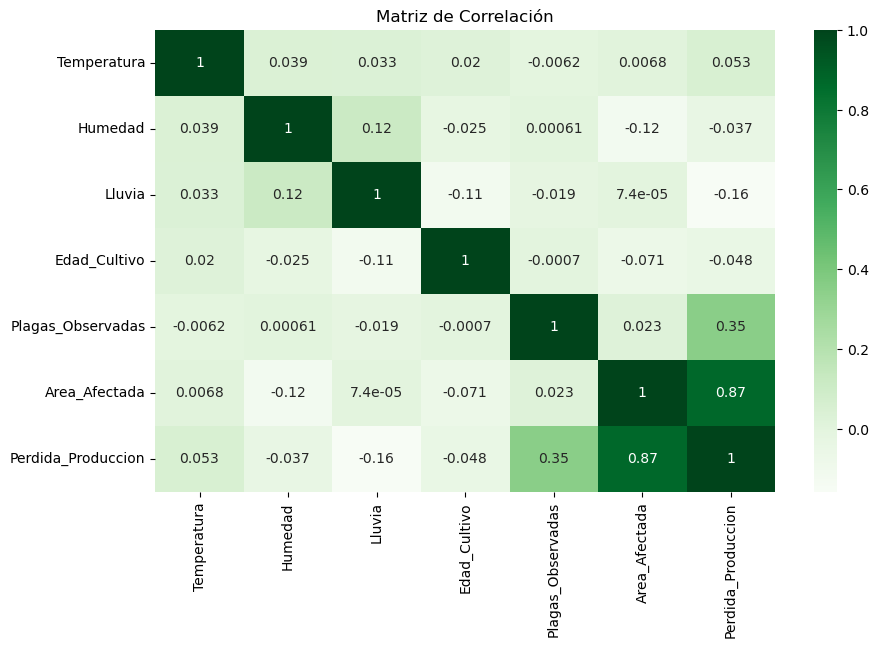

In [36]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),
            annot=True,
            cmap="Greens")
plt.title("Matriz de Correlación")
plt.show()

### Definir las variables independientes y la variable objetivo

En Machine Learning se debe separar la información en dos partes:

- **Variables independientes (X)**: son las variables que el modelo utilizará para aprender (Temperatura, Humedad, Lluvia, Edad del cultivo, Plagas observadas, Área afectada). Se obtienen con `df.drop("Perdida_Produccion", axis=1)`, donde `drop()` elimina la columna indicada y `axis=1` indica que se eliminará una columna.
- **Variable dependiente (y)**: es la variable que queremos predecir, en este caso el porcentaje de pérdida de producción.



In [37]:
X = df.drop("Perdida_Produccion", axis=1)
y = df["Perdida_Produccion"]

## Entrenamiento del modelo y realización de predicciones

Hasta este momento ya tenemos el dataset, las variables independientes (X) y la variable objetivo (y). Ahora el siguiente paso es enseñarle al algoritmo cómo aprender la relación entre esas variables.

### Importar las librerías de Machine Learning

- **train_test_split**: sirve para dividir el dataset en datos de entrenamiento y datos de prueba. Esto permite entrenar el modelo con una parte de la información y después comprobar qué tan bien predice datos que nunca había visto.
- **LinearRegression**: es el algoritmo de Machine Learning que utilizará la práctica. Su objetivo es encontrar la mejor relación entre las variables independientes y la variable objetivo para realizar predicciones.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Dividir el dataset

Antes de entrenar un modelo es necesario separar los datos, porque si el algoritmo aprende con todos los datos, después no tendremos una forma de saber si realmente aprendió o simplemente memorizó la información.

- `test_size=0.2` significa que el 80% de los datos serán utilizados para entrenar y el 20% para evaluar el modelo.
- `random_state=42` hace que la división siempre sea la misma, para que los resultados sean reproducibles.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Verificar el tamaño de los conjuntos

El atributo `shape` permite conocer el tamaño de los conjuntos creados.

In [40]:
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (240, 6)
Datos de prueba: (60, 6)


### Crear el modelo de Regresión Lineal

Aquí se crea el modelo. Todavía no aprende nada, simplemente se crea el objeto llamado `modelo` (como un estudiante que aún no ha recibido ninguna clase).

In [41]:
modelo = LinearRegression()

### Entrenar el modelo

Este es el paso más importante. La función `fit()` entrena el modelo.

¿Qué hace internamente?
1. Analiza los datos de entrenamiento.
2. Busca relaciones entre las variables.
3. Calcula los coeficientes de la ecuación de Regresión Lineal.
4. Guarda esos valores para poder hacer predicciones.

Durante este proceso el algoritmo aprende, por ejemplo, cuánto influye la temperatura, la humedad, el área afectada y el número de plagas. En otras palabras, aprende la relación entre las variables y la pérdida de producción.

In [42]:
modelo.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Mostrar los coeficientes

Una vez entrenado el modelo podemos observar cuánto influye cada variable. Un coeficiente positivo significa que al aumentar esa variable también aumenta la pérdida de producción; un coeficiente negativo significa que al aumentar esa variable disminuye la pérdida de producción.

In [43]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})
coeficientes

,Variable,Coeficiente
0,Temperatura,0.129846
1,Humedad,0.101520
2,Lluvia,-0.030783
3,Edad_Cultivo,-0.019577
4,Plagas_Observadas,0.748780
5,Area_Afectada,0.498545


### Mostrar el intercepto

El intercepto es el valor inicial desde donde comienza la ecuación de la Regresión Lineal. Es el valor que tendría la variable objetivo cuando todas las variables independientes fueran iguales a cero.

In [44]:
print("Intercepto:", modelo.intercept_)

Intercepto: 3.625901292891321


### Realizar predicciones

Ahora el modelo utilizará los datos de prueba para hacer predicciones. La función `predict()` recibe nuevas observaciones y calcula cuál sería la pérdida de producción. Es importante notar que el modelo nunca vio estos datos durante el entrenamiento, por lo que esta etapa sirve para comprobar si realmente aprendió.

In [45]:
predicciones = modelo.predict(X_test)

### Comparar valores reales y predichos

Se crea una nueva tabla para comparar el valor real y el valor predicho por el modelo. Mientras más parecidos sean ambos valores, mejor habrá aprendido el algoritmo.

In [46]:
comparacion = pd.DataFrame({
    "Valor Real": y_test,
    "Predicción": predicciones
})
comparacion.head(10)

,Valor Real,Predicción
203,62.474192,67.544006
266,22.805255,26.698558
152,60.409540,58.970888
9,21.830239,24.196469
233,69.661267,71.009064
226,46.722205,42.495470
196,38.325951,32.096198
109,32.165943,32.894271
5,20.723285,26.589887
175,47.230817,51.302382


### Realizar una predicción con un nuevo cultivo

Aquí simulamos un cultivo nuevo, proporcionando sus características (temperatura, humedad, lluvia, edad del cultivo, plagas observadas y área afectada). El modelo utiliza esa información para estimar el porcentaje de pérdida de producción.



In [47]:
nuevo_cultivo = pd.DataFrame({
    "Temperatura": [30],
    "Humedad": [75],
    "Lluvia": [120],
    "Edad_Cultivo": [8],
    "Plagas_Observadas": [10],
    "Area_Afectada": [35]
})

prediccion = modelo.predict(nuevo_cultivo)
print("Pérdida estimada:", prediccion[0])

Pérdida estimada: 36.221629097499665


## Evaluación del modelo de Regresión Lineal

Una vez que el modelo realiza las predicciones, es necesario compararlas con los valores reales para medir su precisión. Para ello utilizaremos cuatro métricas: **MAE**, **MSE**, **RMSE** y **R²**. Además, generaremos gráficas para visualizar el comportamiento del modelo.

### Importar las métricas de evaluación

- `mean_absolute_error()` calcula el error promedio entre los valores reales y los predichos.
- `mean_squared_error()` calcula el error cuadrático medio, dando mayor importancia a los errores grandes.
- `r2_score()` indica qué tan bien explica el modelo la variación de los datos.

In [48]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

### Calcular el Error Absoluto Medio (MAE)

El MAE mide el error promedio entre los valores reales y los predichos, calculando la diferencia absoluta entre cada valor real y su predicción y luego obteniendo el promedio. Mientras más pequeño sea el MAE, mejor será el modelo (0 significaría que el modelo predijo todos los valores correctamente).

In [49]:
mae = mean_absolute_error(y_test, predicciones)
print("MAE:", mae)

MAE: 3.6987290265906907


### Calcular el Error Cuadrático Medio (MSE)

El MSE también mide el error, pero antes de promediarlo eleva cada diferencia al cuadrado. Esto hace que los errores grandes tengan un mayor impacto en el resultado. Cuanto menor sea el MSE, mejor será el modelo.

In [50]:
mse = mean_squared_error(y_test, predicciones)
print("MSE:", mse)

MSE: 21.906421183343916


### Calcular la Raíz del Error Cuadrático Medio (RMSE)

El RMSE es la raíz cuadrada del MSE. Su principal ventaja es que se expresa en las mismas unidades que la variable objetivo (Pérdida de Producción %), por lo que suele ser más fácil de interpretar que el MSE.

In [51]:
rmse = np.sqrt(mse)
print("RMSE:", rmse)

RMSE: 4.6804295938881415


### Calcular el coeficiente de determinación (R²)

El R² indica qué porcentaje de la variación de la variable objetivo es explicado por el modelo. Su valor está entre 0 y 1: mientras más cercano a 1, mejor es el modelo (1.00 predicción perfecta, 0.90 excelente modelo, 0.80 muy buen modelo, 0.60 modelo aceptable, 0.30 baja precisión, 0.00 no explica los datos).

In [52]:
r2 = r2_score(y_test, predicciones)
print("R²:", r2)

R²: 0.9299501758536122


### Comparar valores reales y predicciones mediante una gráfica

Esta gráfica permite comparar visualmente los valores reales con los predichos. Cada punto representa un registro del conjunto de prueba: el eje X muestra los valores reales y el eje Y muestra las predicciones realizadas por el modelo. Mientras más cerca estén los puntos de una línea diagonal imaginaria, mejor será el desempeño del modelo.

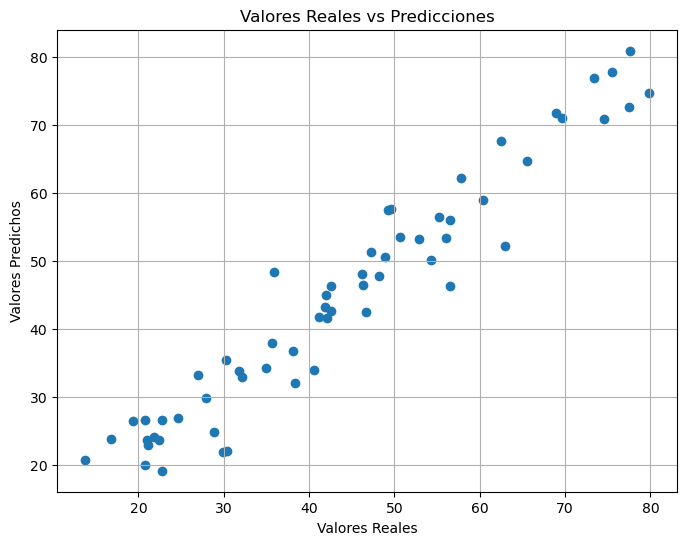

In [53]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, predicciones)
plt.xlabel("Valores Reales")
plt.ylabel("Valores Predichos")
plt.title("Valores Reales vs Predicciones")
plt.grid(True)
plt.show()

### Graficar la importancia de los coeficientes

Esta gráfica muestra la influencia de cada variable sobre la pérdida de producción. Las barras más grandes indican las variables con mayor impacto. En este ejemplo es normal observar que **Plagas_Observadas** tenga uno de los coeficientes más altos, **Area_Afectada** también influya significativamente, y **Lluvia** tenga un coeficiente negativo, indicando que puede reducir ligeramente la pérdida en este conjunto de datos simulado.

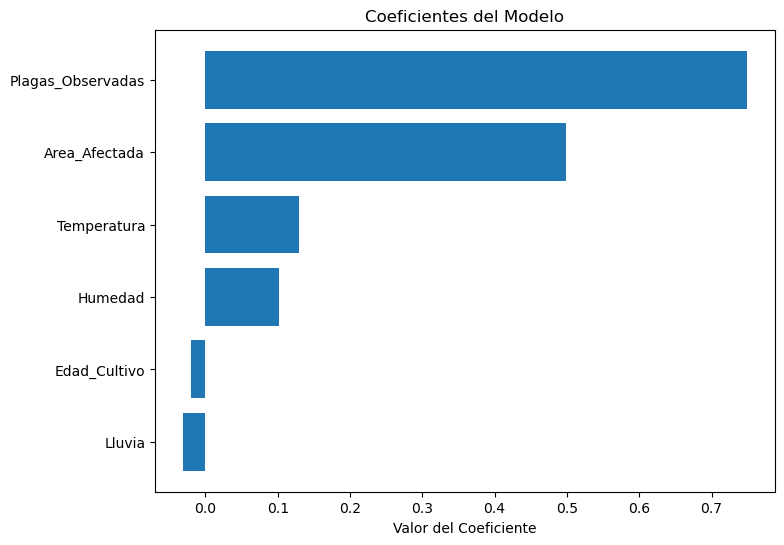

In [54]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": modelo.coef_
})
coeficientes = coeficientes.sort_values(by="Coeficiente")

plt.figure(figsize=(8,6))
plt.barh(coeficientes["Variable"], coeficientes["Coeficiente"])
plt.title("Coeficientes del Modelo")
plt.xlabel("Valor del Coeficiente")
plt.show()

### Conclusiones

La práctica permitió aplicar el algoritmo de Regresión Lineal para estimar la pérdida de producción en cultivos de caña de azúcar a partir de variables ambientales y del nivel de infestación de plagas.

Se creó un conjunto de datos ficticio con 300 registros que simuló condiciones reales de cultivo. Posteriormente, los datos fueron explorados y preparados para el entrenamiento del modelo.

El algoritmo fue entrenado utilizando el 80% de los datos y evaluado con el 20% restante. Finalmente, se calcularon métricas como MAE, MSE, RMSE y R², las cuales permitieron medir el desempeño del modelo.

Gracias a este proceso fue posible estimar la pérdida de producción de un nuevo cultivo utilizando únicamente sus características, demostrando cómo la Regresión Lineal puede emplearse para realizar predicciones basadas en datos históricos.